In [53]:
# Importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [54]:
fandango = pd.read_csv("fandango_scrape.csv")

# Understandig the data

In [55]:
fandango.head()

,FILM,STARS,RATING,VOTES
0,Fifty Shades of Grey (2015),4.0,3.9,34846
1,Jurassic World (2015),4.5,4.5,34390
2,American Sniper (2015),5.0,4.8,34085
3,Furious 7 (2015),5.0,4.8,33538
4,Inside Out (2015),4.5,4.5,15749


In [56]:
fandango.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FILM    504 non-null    str    
 1   STARS   504 non-null    float64
 2   RATING  504 non-null    float64
 3   VOTES   504 non-null    int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 15.9 KB


In [57]:
fandango.describe()

,STARS,RATING,VOTES
count,504.000000,504.000000,504.000000
mean,3.558532,3.375794,1147.863095
std,1.563133,1.491223,3830.583136
min,0.000000,0.000000,0.000000
25%,3.500000,3.100000,3.000000
50%,4.000000,3.800000,18.500000
75%,4.500000,4.300000,189.750000
max,5.000000,5.000000,34846.000000


<Axes: xlabel='RATING', ylabel='VOTES'>

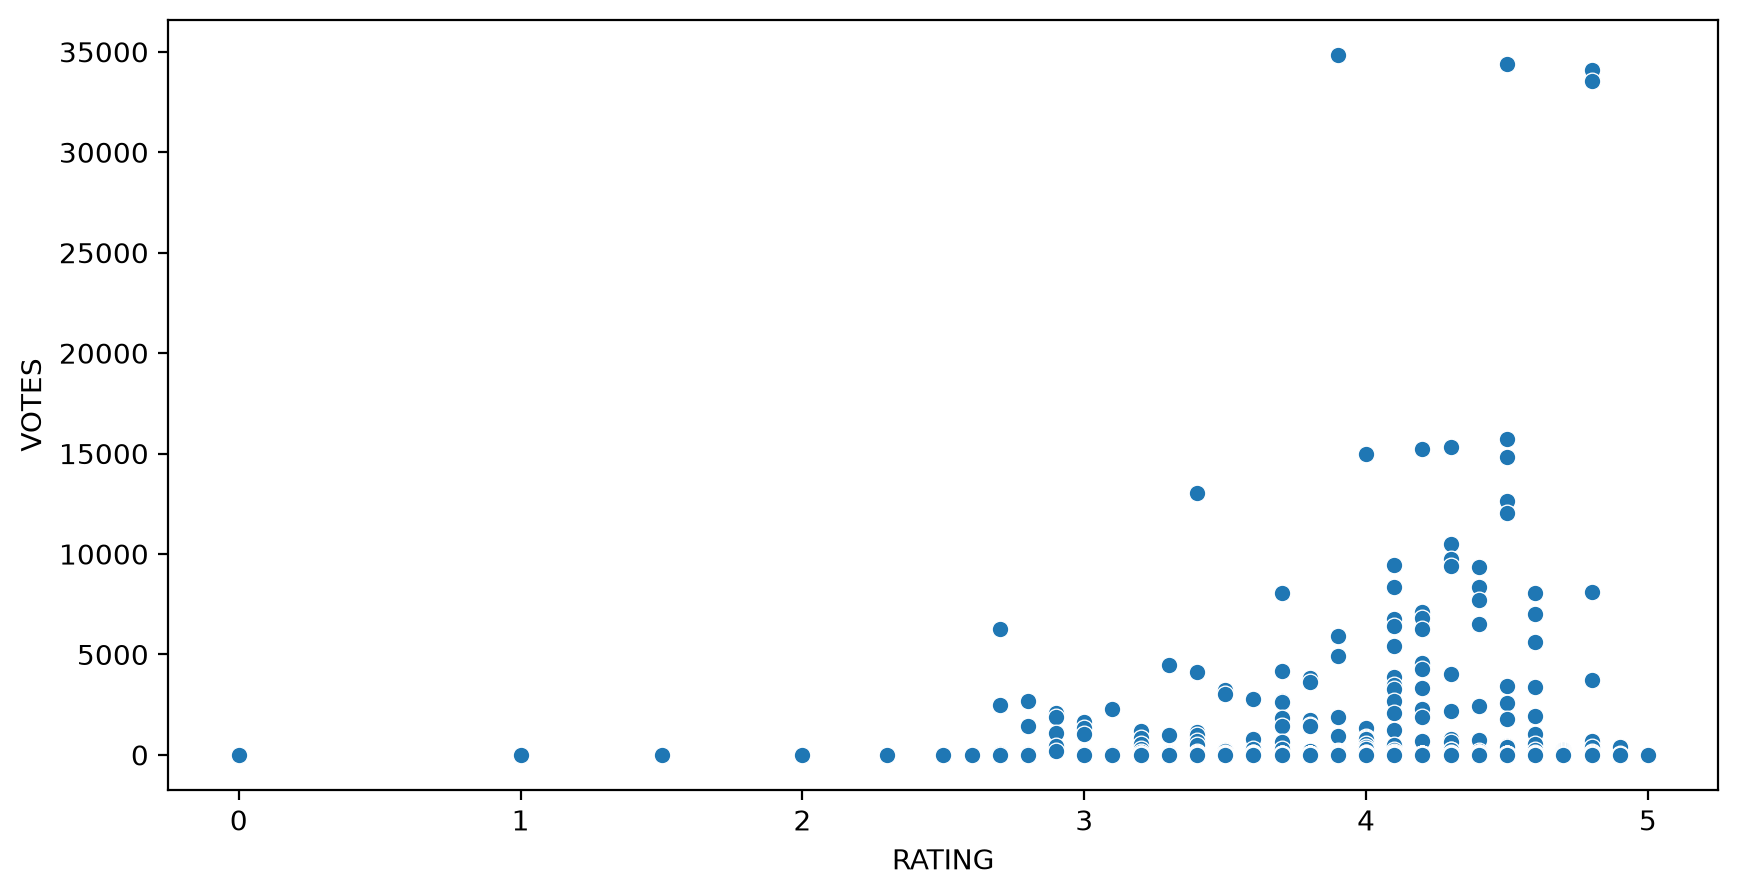

In [58]:
plt.figure(figsize=(10,5), dpi = 200)
sns.scatterplot(data= fandango, x = "RATING", y = "VOTES")

In [59]:
fandango.corr(numeric_only=True)

,STARS,RATING,VOTES
STARS,1.000000,0.994696,0.164218
RATING,0.994696,1.000000,0.163764
VOTES,0.164218,0.163764,1.000000


In [60]:

# Separating the year of the film and setting it to a new column

title = "Film Title Name (Year)"
title.split("(")[-1].replace(")", "")

fandango["YEAR"] = fandango["FILM"].apply(lambda title: title.split("(")[-1].replace(")", ""))
fandango["YEAR"]

0      2015
1      2015
2      2015
3      2015
4      2015
       ... 
499    2015
500    2015
501    2015
502    1964
503    2012
Name: YEAR, Length: 504, dtype: str

In [61]:

fandango.head()

,FILM,STARS,RATING,VOTES,YEAR
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015
1,Jurassic World (2015),4.5,4.5,34390,2015
2,American Sniper (2015),5.0,4.8,34085,2015
3,Furious 7 (2015),5.0,4.8,33538,2015
4,Inside Out (2015),4.5,4.5,15749,2015


In [62]:
# No. of movies per year

fandango.value_counts(subset="YEAR")

YEAR
2015    478
2014     23
2016      1
1964      1
2012      1
Name: count, dtype: int64

<Axes: xlabel='YEAR', ylabel='count'>

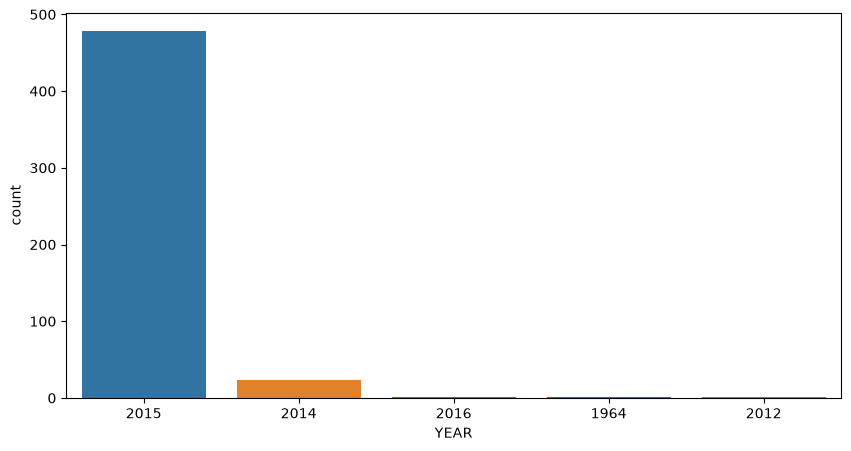

In [63]:
# PLotting count of movies per year

plt.figure(figsize=(10,5))
sns.countplot(data=fandango, x = "YEAR", hue = "YEAR")

In [64]:
# 10 movies with the largest number of votes

fandango.nlargest(10, "VOTES")

,FILM,STARS,RATING,VOTES,YEAR
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015
1,Jurassic World (2015),4.5,4.5,34390,2015
2,American Sniper (2015),5.0,4.8,34085,2015
3,Furious 7 (2015),5.0,4.8,33538,2015
4,Inside Out (2015),4.5,4.5,15749,2015
5,The Hobbit: The Battle of the Five Armies (2014),4.5,4.3,15337,2014
6,Kingsman: The Secret Service (2015),4.5,4.2,15205,2015
7,Minions (2015),4.0,4.0,14998,2015
8,Avengers: Age of Ultron (2015),5.0,4.5,14846,2015
9,Into the Woods (2014),3.5,3.4,13055,2014


In [65]:
# movies with zero votes

(fandango["VOTES"] == 0).sum()

np.int64(69)

In [66]:
# Building a dataframe of only reviewed films by removing any films that have zero votes

fan_reviewd = fandango[fandango["VOTES"]>0]
fan_reviewd

,FILM,STARS,RATING,VOTES,YEAR
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015
1,Jurassic World (2015),4.5,4.5,34390,2015
2,American Sniper (2015),5.0,4.8,34085,2015
3,Furious 7 (2015),5.0,4.8,33538,2015
4,Inside Out (2015),4.5,4.5,15749,2015
...,...,...,...,...,...
430,That Sugar Film (2015),5.0,5.0,1,2015
431,The Intern (2015),5.0,5.0,1,2015
432,The Park Bench (2015),5.0,5.0,1,2015
433,The Wanted 18 (2015),5.0,5.0,1,2015


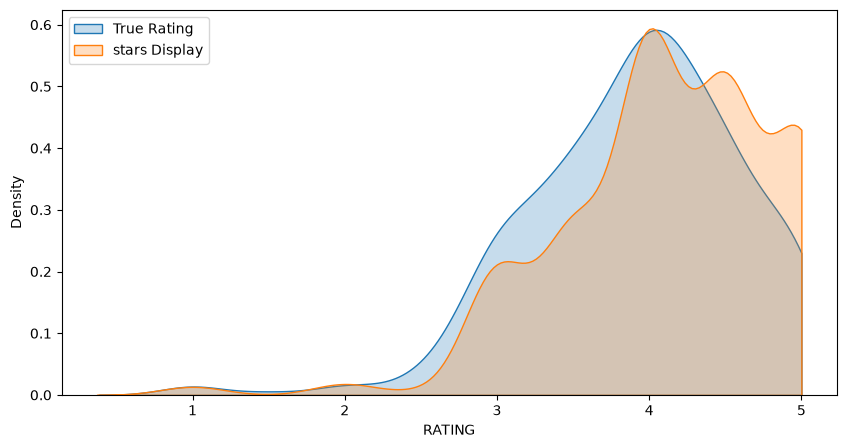

In [67]:
# Creating a KDE plot
plt.figure(figsize=(10,5))
sns.kdeplot(data = fan_reviewd, x = "RATING", clip=[0,5], fill=True, label = "True Rating")
sns.kdeplot(data = fan_reviewd, x = "STARS", clip=[0,5], fill=True, label = "stars Display")

plt.legend()

In [68]:
fan_reviewd["DISCREPANCY"] = fan_reviewd["STARS"] - fan_reviewd["RATING"]
fan_reviewd.head()
fan_reviewd["DISCREPANCY"] = fan_reviewd["DISCREPANCY"].round(2)

<Axes: xlabel='DISCREPANCY', ylabel='count'>

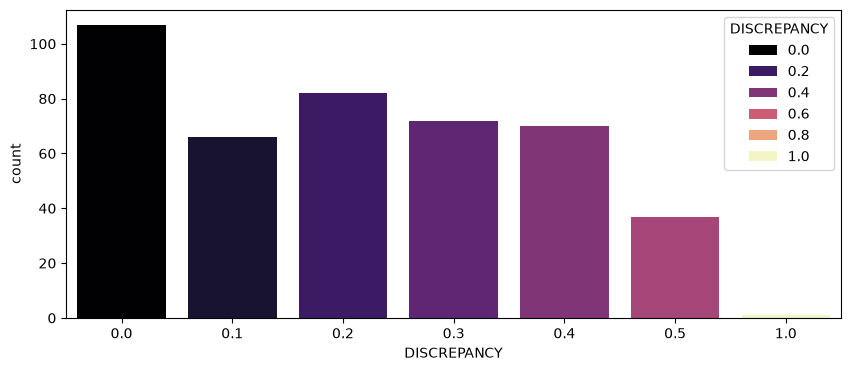

In [69]:
# Creating a count plot displaying the no. of times a certain difference occurs

plt.figure(figsize=(10,4))
sns.countplot(data = fan_reviewd, x="DISCREPANCY", hue = "DISCREPANCY", palette="magma")

In [70]:
# Movie with 1 star difference

fan_reviewd[fan_reviewd["DISCREPANCY"] == 1]

,FILM,STARS,RATING,VOTES,YEAR,DISCREPANCY
381,Turbo Kid (2015),5.0,4.0,2,2015,1.0


# Comparison of Fandango Ratings to other sites

In [71]:
all_sites = pd.read_csv("all_sites_scores.csv")
all_sites.head()

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count
0,Avengers: Age of Ultron (2015),74,86,66,7.1,7.8,1330,271107
1,Cinderella (2015),85,80,67,7.5,7.1,249,65709
2,Ant-Man (2015),80,90,64,8.1,7.8,627,103660
3,Do You Believe? (2015),18,84,22,4.7,5.4,31,3136
4,Hot Tub Time Machine 2 (2015),14,28,29,3.4,5.1,88,19560


In [72]:
all_sites.info()

<class 'pandas.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FILM                        146 non-null    str    
 1   RottenTomatoes              146 non-null    int64  
 2   RottenTomatoes_User         146 non-null    int64  
 3   Metacritic                  146 non-null    int64  
 4   Metacritic_User             146 non-null    float64
 5   IMDB                        146 non-null    float64
 6   Metacritic_user_vote_count  146 non-null    int64  
 7   IMDB_user_vote_count        146 non-null    int64  
dtypes: float64(2), int64(5), str(1)
memory usage: 9.3 KB


### Rotten Tomatoes

In [73]:
all_sites.describe()

,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,60.849315,63.876712,58.808219,6.519178,6.736986,185.705479,42846.205479
std,30.168799,20.024430,19.517389,1.510712,0.958736,316.606515,67406.509171
min,5.000000,20.000000,13.000000,2.400000,4.000000,4.000000,243.000000
25%,31.250000,50.000000,43.500000,5.700000,6.300000,33.250000,5627.000000
50%,63.500000,66.500000,59.000000,6.850000,6.900000,72.500000,19103.000000
75%,89.000000,81.000000,75.000000,7.500000,7.400000,168.500000,45185.750000
max,100.000000,94.000000,94.000000,9.600000,8.600000,2375.000000,334164.000000


(0.0, 100.0)

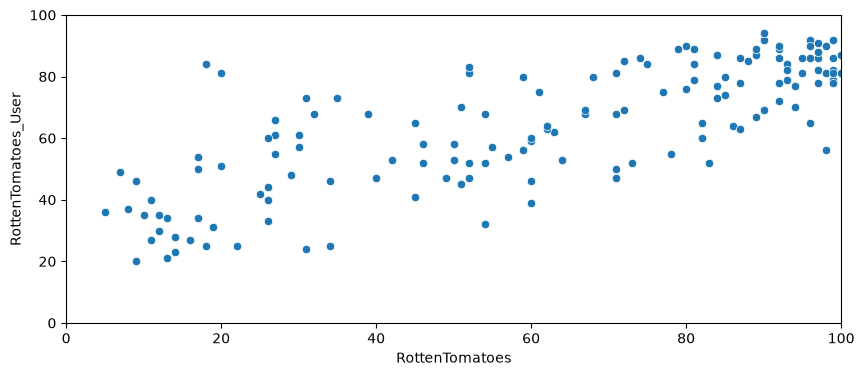

In [74]:
# Scatterplot exploring relatioship between Rotten Tomatoes Critics revies and Rotten Tomatoes user reviews

plt.figure(figsize=(10,4))
sns.scatterplot(data=all_sites, x = "RottenTomatoes", y = "RottenTomatoes_User")
plt.ylim(0,100)
plt.xlim(0,100)


In [75]:
all_sites["Rotten_Diff"] = all_sites["RottenTomatoes"] - all_sites["RottenTomatoes_User"]
all_sites["Rotten_Diff"].round(2)

0     -12
1       5
2     -10
3     -66
4     -14
       ..
141     9
142    15
143    19
144    19
145    24
Name: Rotten_Diff, Length: 146, dtype: int64

In [76]:
# finding the spread diff between Rotten Tomatoes scores and Rotten Tomatoes user scores

# mean absolute deviation
all_sites["Rotten_Diff"].apply(abs).mean()

# standard deviation
all_sites["Rotten_Diff"].std()

np.float64(19.156684331019743)

<Axes: xlabel='Rotten_Diff', ylabel='Count'>

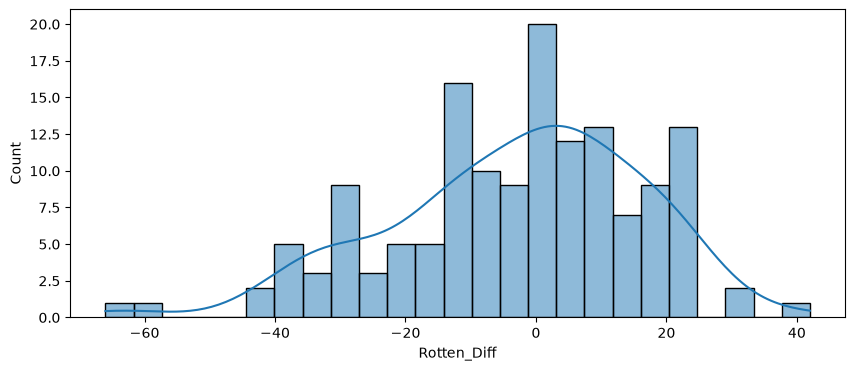

In [77]:
# Plotting Rotten_Diff

plt.figure(figsize=(10,4))
sns.histplot(data=all_sites, x = "Rotten_Diff", kde=True, bins = 25)

<Axes: xlabel='Rotten_Diff', ylabel='Count'>

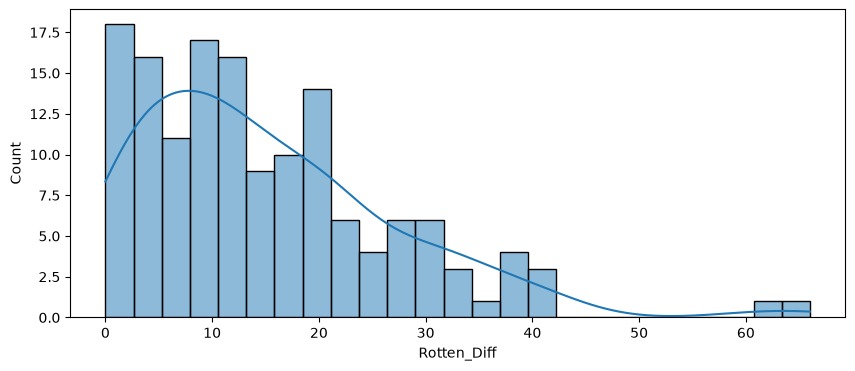

In [78]:
# Distribution showing the AMD between critics and users on Rotten Tomatoes
plt.figure(figsize=(10,4))
sns.histplot(x = all_sites["Rotten_Diff"].apply(abs), kde=True, bins = 25)


In [79]:
# movies the users scored higher than critics on RT

all_sites.nsmallest(5, "Rotten_Diff")["FILM"]

3         Do You Believe? (2015)
85             Little Boy (2015)
105      Hitman: Agent 47 (2015)
134      The Longest Ride (2015)
125    The Wedding Ringer (2015)
Name: FILM, dtype: str

In [80]:
# movies the critics scored higher than users on RT

all_sites.nlargest(5, "Rotten_Diff")["FILM"]

69                    Mr. Turner (2014)
112                   It Follows (2015)
115            While We're Young (2015)
37                 Welcome to Me (2015)
40     I'll See You In My Dreams (2015)
Name: FILM, dtype: str

### MetaCritics

(0.0, 10.0)

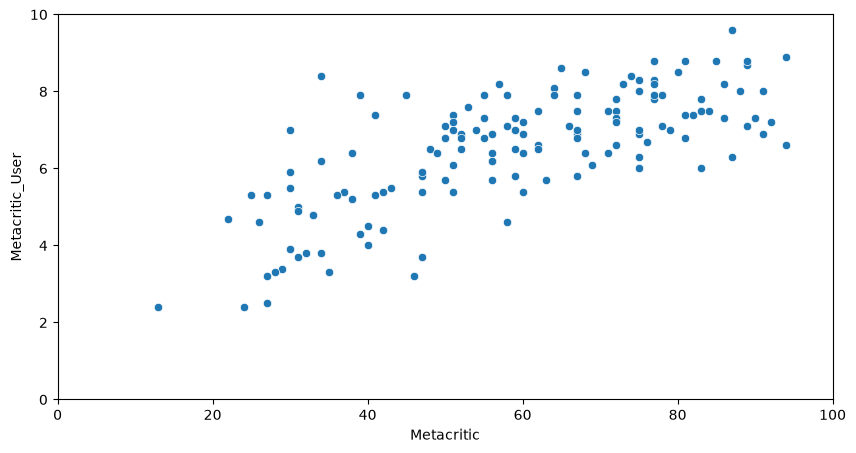

In [81]:
# scatterplot of MetaCritic rating versus the Metacritic User rating

plt.figure(figsize=(10,5))
sns.scatterplot(data=all_sites, x = "Metacritic", y = "Metacritic_User")
plt.xlim(0,100)
plt.ylim(0,10)

### IMDB

<Axes: xlabel='Metacritic_user_vote_count', ylabel='IMDB_user_vote_count'>

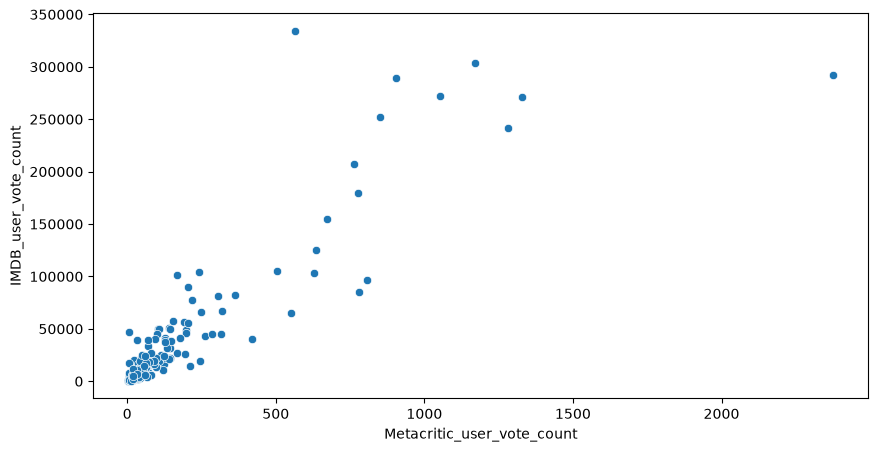

In [82]:
# scatterplot of vote counts on MetaCritic versus vote counts on IMDB

plt.figure(figsize=(10,5))
sns.scatterplot(data=all_sites, x = "Metacritic_user_vote_count", y = "IMDB_user_vote_count")

In [83]:
# exploring the two outliers in the above graph
all_sites.nlargest(1, "Metacritic_user_vote_count")["FILM"]


88    Mad Max: Fury Road (2015)
Name: FILM, dtype: str

In [84]:
all_sites.nlargest(1, "IMDB_user_vote_count")["FILM"]

14    The Imitation Game (2014)
Name: FILM, dtype: str

# Did Fandango artifically boost movie ratings to sell tickets?

In [87]:
df = pd.merge(fandango, all_sites, on = "FILM", how="inner")
df.head()

,FILM,STARS,RATING,VOTES,YEAR,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,Rotten_Diff
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015,25,42,46,3.2,4.2,778,179506,-17
1,Jurassic World (2015),4.5,4.5,34390,2015,71,81,59,7.0,7.3,1281,241807,-10
2,American Sniper (2015),5.0,4.8,34085,2015,72,85,72,6.6,7.4,850,251856,-13
3,Furious 7 (2015),5.0,4.8,33538,2015,81,84,67,6.8,7.4,764,207211,-3
4,Inside Out (2015),4.5,4.5,15749,2015,98,90,94,8.9,8.6,807,96252,8


In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FILM                        145 non-null    str    
 1   STARS                       145 non-null    float64
 2   RATING                      145 non-null    float64
 3   VOTES                       145 non-null    int64  
 4   YEAR                        145 non-null    str    
 5   RottenTomatoes              145 non-null    int64  
 6   RottenTomatoes_User         145 non-null    int64  
 7   Metacritic                  145 non-null    int64  
 8   Metacritic_User             145 non-null    float64
 9   IMDB                        145 non-null    float64
 10  Metacritic_user_vote_count  145 non-null    int64  
 11  IMDB_user_vote_count        145 non-null    int64  
 12  Rotten_Diff                 145 non-null    int64  
dtypes: float64(4), int64(7), str(2)
memory usage: 

In [89]:
df.describe().transpose()["max"]

STARS                              5.0
RATING                             4.8
VOTES                          34846.0
RottenTomatoes                   100.0
RottenTomatoes_User               94.0
Metacritic                        94.0
Metacritic_User                    9.6
IMDB                               8.6
Metacritic_user_vote_count      2375.0
IMDB_user_vote_count          334164.0
Rotten_Diff                       42.0
Name: max, dtype: float64

In [91]:
# Normalizing columns to Fandango STARS adn RATINGS 0-5
df["RT_Norm"] = np.round(df["RottenTomatoes"]/20,1)
df["RTuser_Norm"] = np.round(df["RottenTomatoes_User"]/20,1)


In [92]:
df["Meta_Norm"] = np.round(df["Metacritic"]/20,1)
df["Metauser_Norm"] = np.round(df["Metacritic_User"]/2,1)

In [94]:
df["IMDB_Norm"] = np.round(df["IMDB"]/2,1)


In [96]:
df.head()

,FILM,STARS,RATING,VOTES,YEAR,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,Rotten_Diff,RT_Norm,RTuser_Norm,Meta_Norm,Metauser_Norm,IMDB_Norm
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015,25,42,46,3.2,4.2,778,179506,-17,1.2,2.1,2.3,1.6,2.1
1,Jurassic World (2015),4.5,4.5,34390,2015,71,81,59,7.0,7.3,1281,241807,-10,3.6,4.0,3.0,3.5,3.6
2,American Sniper (2015),5.0,4.8,34085,2015,72,85,72,6.6,7.4,850,251856,-13,3.6,4.2,3.6,3.3,3.7
3,Furious 7 (2015),5.0,4.8,33538,2015,81,84,67,6.8,7.4,764,207211,-3,4.0,4.2,3.4,3.4,3.7
4,Inside Out (2015),4.5,4.5,15749,2015,98,90,94,8.9,8.6,807,96252,8,4.9,4.5,4.7,4.4,4.3


In [98]:
df.columns

Index(['FILM', 'STARS', 'RATING', 'VOTES', 'YEAR', 'RottenTomatoes',
       'RottenTomatoes_User', 'Metacritic', 'Metacritic_User', 'IMDB',
       'Metacritic_user_vote_count', 'IMDB_user_vote_count', 'Rotten_Diff',
       'RT_Norm', 'RTuser_Norm', 'Meta_Norm', 'Metauser_Norm', 'IMDB_Norm'],
      dtype='str')

In [99]:
norm_scores = df[['STARS', 'RATING', 'RT_Norm', 'RTuser_Norm', 'Meta_Norm', 'Metauser_Norm', 'IMDB_Norm']]
norm_scores

,STARS,RATING,RT_Norm,RTuser_Norm,Meta_Norm,Metauser_Norm,IMDB_Norm
0,4.0,3.9,1.2,2.1,2.3,1.6,2.1
1,4.5,4.5,3.6,4.0,3.0,3.5,3.6
2,5.0,4.8,3.6,4.2,3.6,3.3,3.7
3,5.0,4.8,4.0,4.2,3.4,3.4,3.7
4,4.5,4.5,4.9,4.5,4.7,4.4,4.3
...,...,...,...,...,...,...,...
140,3.5,3.5,4.4,3.2,3.4,3.2,3.4
141,4.0,3.6,4.8,4.0,4.4,3.2,3.5
142,4.5,4.2,4.6,4.2,3.4,3.5,3.9
143,4.0,3.9,4.8,4.3,4.3,3.6,3.7


<Axes: ylabel='Density'>

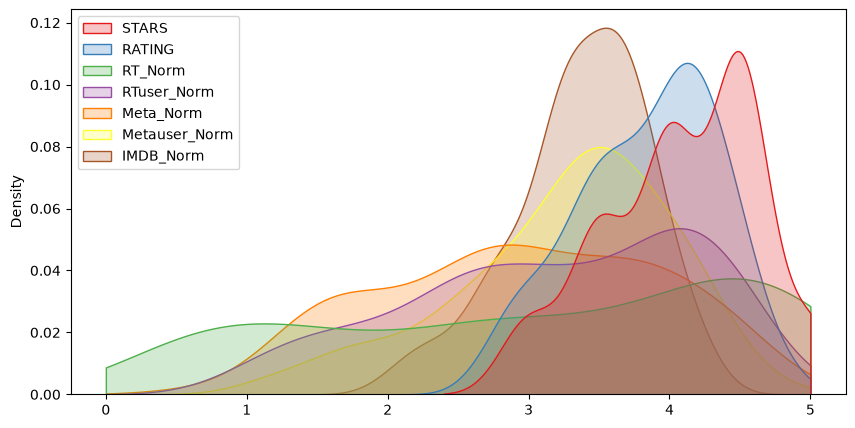

In [105]:
# Comparing distribution of scores across sites

plt.figure(figsize=(10,5))
sns.kdeplot(data=norm_scores, fill=True, clip=[0,5], palette="Set1")

<Axes: ylabel='Density'>

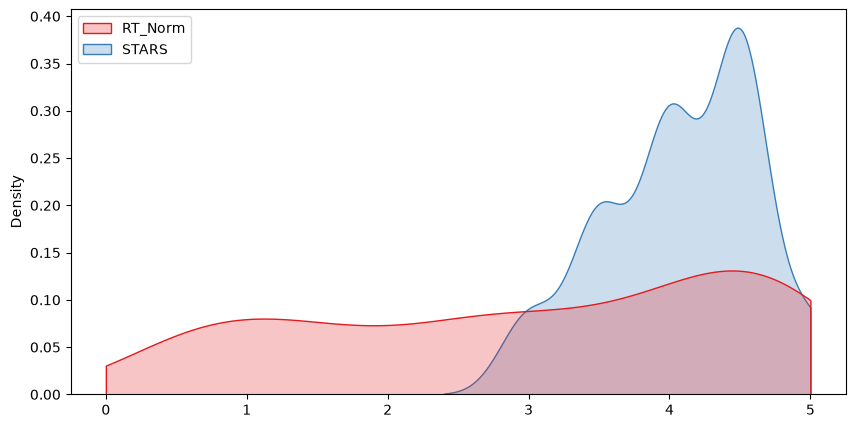

In [ ]:
# KDE plot comparing the distribution of RT critics ratings against the STARS displayed by Fandango


sns.kdeplot(data=norm_scores[["RT_Norm", "STARS"]], fill=True, clip=[0,5], palette="Set1")plt.figure(figsize=(10,5))

<Axes: ylabel='Count'>

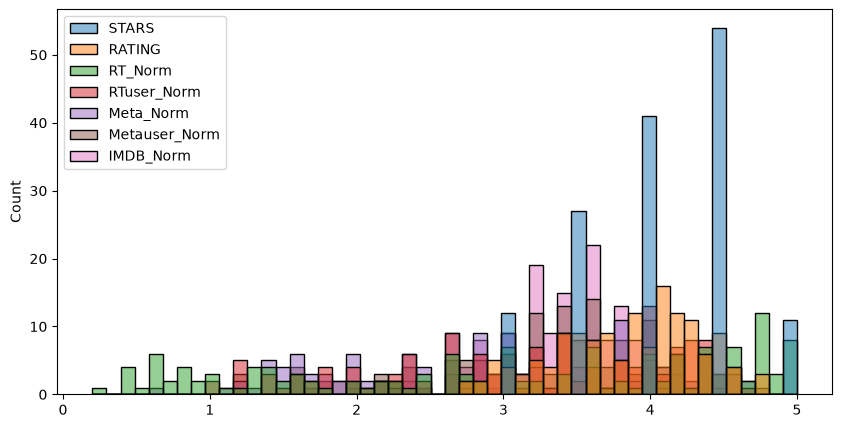

In [111]:
# comparing all normalised scores

plt.figure(figsize=(10,5))
sns.histplot(data=norm_scores, bins=50)

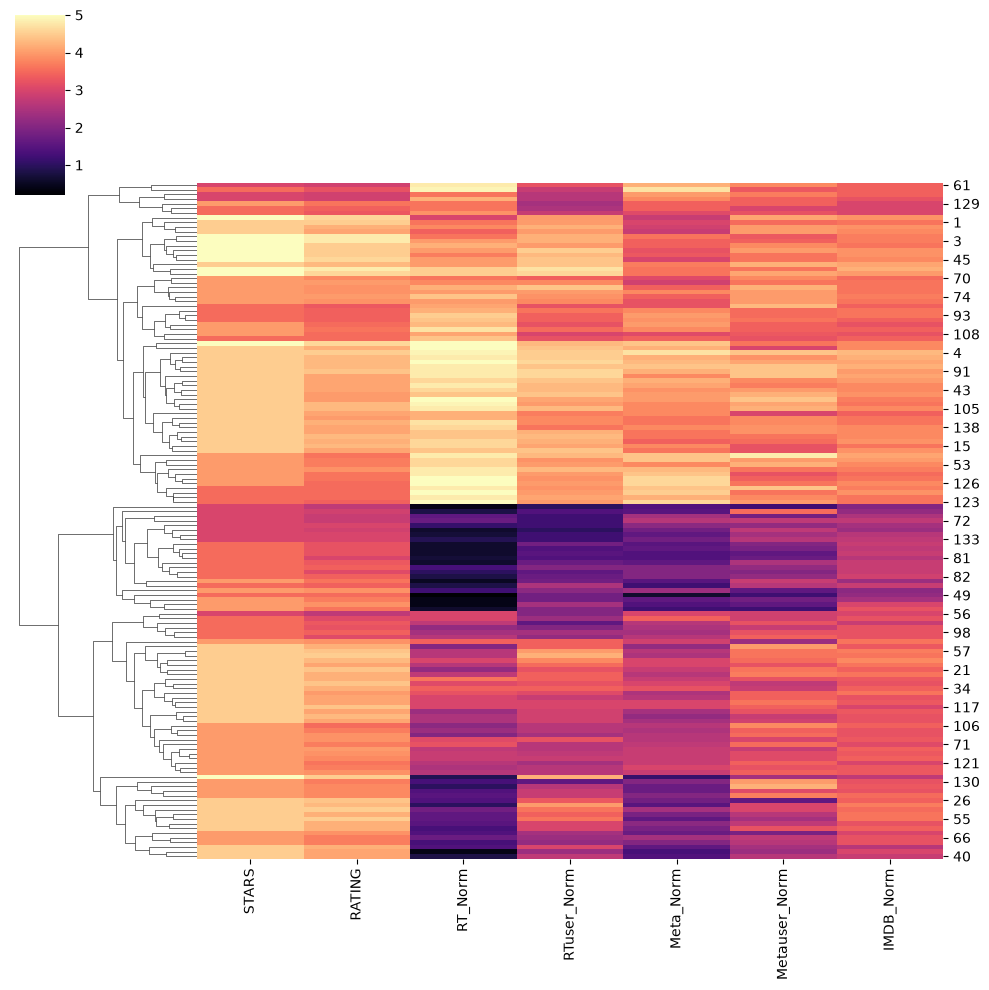

In [ ]:

sns.clustermap(data=norm_scores, cmap = "magma", col_cluster=False)

In [119]:
norm_scores.columns

Index(['STARS', 'RATING', 'RT_Norm', 'RTuser_Norm', 'Meta_Norm',
       'Metauser_Norm', 'IMDB_Norm'],
      dtype='str')

In [ ]:
norm_films = df[['FILM', 'STARS', 'RATING', 'RT_Norm', 'RTuser_Norm', 'Meta_Norm','Metauser_Norm', 'IMDB_Norm']]

In [127]:
# worst movies across all platforms, based on RT critics

worst_films = norm_films.nsmallest(10, "RT_Norm")

<Axes: ylabel='Density'>

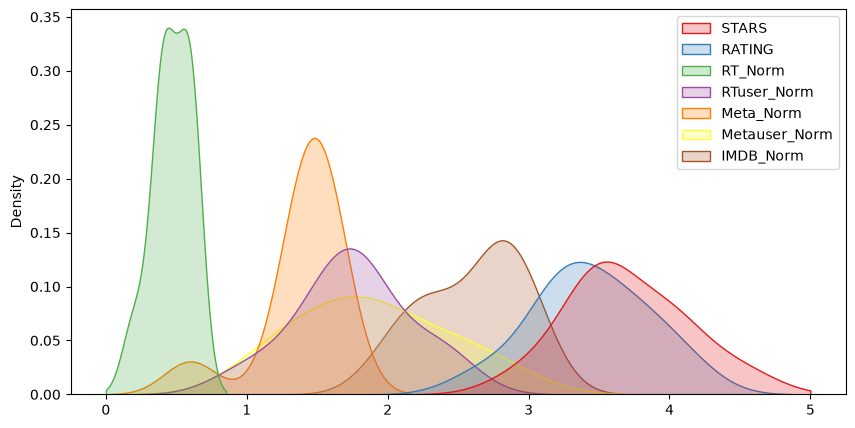

In [128]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=worst_films, fill=True, clip=[0,5], palette="Set1")
